In [3]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
def carregar_dados():
    """Carrega o dataset Digits (Números Manuscritos)."""
    digits = load_digits()
    X = digits.data
    y = digits.target
    # Converte os rótulos [0, 1, ... 9] para formato de texto (string)
    target_names = [str(i) for i in digits.target_names]
    
    return X, y, target_names

In [5]:
def treinar_modelo(X_train, y_train):
    """Instancia e treina o classificador SVM."""
    # O parâmetro gamma=0.001 é um valor clássico recomendado para o dataset Digits
    model = SVC(gamma=0.001)
    model.fit(X_train, y_train)
    return model

In [6]:
def avaliar_modelo(model, X_test, y_test, target_names):
    """Avalia o modelo e exibe as métricas de desempenho."""
    y_pred = model.predict(X_test)
    
    acuracia = accuracy_score(y_test, y_pred)
    print(f"Acurácia do Modelo: {acuracia:.4f}\n")
    
    print("Relatório de Classificação:")
    print(classification_report(y_test, y_pred, target_names=target_names))
    
    # Gerar e salvar a Matriz de Confusão como imagem
    cm = confusion_matrix(y_test, y_pred)
    
    # Aumentamos o figsize para 8x6 para comportar bem a matriz 10x10
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.ylabel('Real')
    plt.xlabel('Predito')
    plt.title('Matriz de Confusão - Reconhecimento de Dígitos')
    
    os.makedirs('resultados', exist_ok=True)
    plt.savefig('resultados/matriz_confusao.png')
    print("Matriz de confusão salva em 'resultados/matriz_confusao.png'")

Iniciando o projeto de classificação de dígitos...

Acurácia do Modelo: 0.9889

Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.95      1.00      0.97        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       1.00      1.00      1.00        36
           5       1.00      1.00      1.00        37
           6       1.00      0.97      0.99        36
           7       0.97      1.00      0.99        36
           8       0.97      0.94      0.96        35
           9       1.00      0.97      0.99        36

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360

Matriz de confusão salva em 'resultados/matriz_confusao.png'


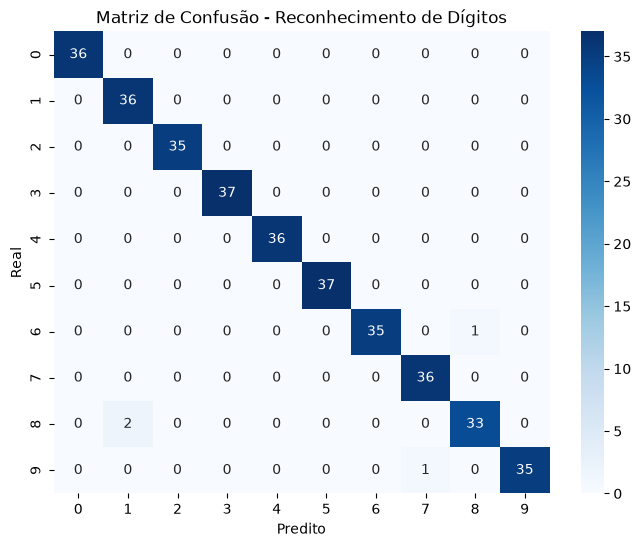

In [ ]:


if __name__ == "__main__":
    print("Iniciando o projeto de classificação de dígitos...\n")
    
    X, y, nomes_classes = carregar_dados()
    
    # 2. Dividir em Treino (80%) e Teste (20%)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # 3. Treinar
    modelo_svm = treinar_modelo(X_train, y_train)
    
    # 4. Avaliar
    avaliar_modelo(modelo_svm, X_test, y_test, nomes_classes)

In [10]:
X, y, nomes_classes = carregar_dados()

# Definimos 2 novos valores de semente para sortear novas amostras de dados
sementes_novas = [10, 99] 

for indice, seed in enumerate(sementes_novas, start=2):
    print(f"--- Gerando Amostra {indice} (Random State = {seed}) ---")
    
    # Divisão 80/20 usando a nova semente de sorteio
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )
    
    # Treinamento com o parâmetro padrão gamma=0.001
    modelo_s = SVC(gamma=0.001)
    modelo_s.fit(X_train_s, y_train_s)
    
    # Predição e Acurácia
    y_pred_s = modelo_s.predict(X_test_s)
    acc_s = accuracy_score(y_test_s, y_pred_s)
    print(f"Acurácia da Amostra {indice}: {acc_s*100:.2f}%")
    
    # Gerando a Matriz de Confusão específica desta nova amostra
    cm_s = confusion_matrix(y_test_s, y_pred_s)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_s, annot=True, fmt='d', cmap='Blues',
                xticklabels=nomes_classes, yticklabels=nomes_classes)
    plt.ylabel('Real')
    plt.xlabel('Predito')
    plt.title(f'Matriz de Confusão - Amostra {indice} (Random State {seed})')
    
    # Salva com um nome único para não sobrescrever a primeira
    caminho_arquivo = f'resultados/matriz_confusao_amostra_{indice}.png'
    plt.savefig(caminho_arquivo)
    plt.close() # Fecha a janela do gráfico para não acumular memória no Jupyter
    print(f"Gráfico salvo com sucesso em: '{caminho_arquivo}'\n")

--- Gerando Amostra 2 (Random State = 10) ---
Acurácia da Amostra 2: 98.89%
Gráfico salvo com sucesso em: 'resultados/matriz_confusao_amostra_2.png'

--- Gerando Amostra 3 (Random State = 99) ---
Acurácia da Amostra 3: 98.61%
Gráfico salvo com sucesso em: 'resultados/matriz_confusao_amostra_3.png'



In [ ]:
def executar_analise_sensibilidade(X, y):
    # 1: O impacto do Gamma (Hiperparâmetro do Kernel)
    # Fixos: test_size=0.2, random_state=42
    print("1: Variação do Gamma")
    gammas = [0.0001, 0.001, 0.01, 0.1]
    acc_gammas = []
    
    for g in gammas:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )
        model = SVC(gamma=g)
        model.fit(X_train, y_train)
        acc = accuracy_score(y_test, model.predict(X_test))
        acc_gammas.append(acc)
        print(f"Gamma: {g:<6} -> Acurácia: {acc*100:.2f}%")
        
    # 2: Proporção da Divisão Treino/Teste
    # Fixos: gamma=0.001, random_state=42
    print("\n2: Proporção Treino / Teste")
    proporcoes = [0.1, 0.2, 0.3, 0.5] # 10%, 20%, 30% e 50% para teste
    
    for prop in proporcoes:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=prop, random_state=42, stratify=y
        )
        model = SVC(gamma=0.001)
        model.fit(X_train, y_train)
        acc = accuracy_score(y_test, model.predict(X_test))
        print(f"Teste: {int(prop*100)}% | Treino: {int((1-prop)*100)}% -> Acurácia: {acc*100:.2f}%")

    # 3: Alteração do Random State
    # Fixos: test_size=0.2, gamma=0.001
    print("\n3: Mudança do Random State")
    states = [10, 23, 87, 99] # testes além do 42
    
    for r in states:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=r, stratify=y
        )
        model = SVC(gamma=0.001)
        model.fit(X_train, y_train)
        acc = accuracy_score(y_test, model.predict(X_test))
        print(f"Random State: {r:<2} -> Acurácia: {acc*100:.2f}%")

    # Geração do Gráfico para o Experimento do Gamma
    plt.figure(figsize=(7, 4))
    plt.plot([str(g) for g in gammas], acc_gammas, marker='o', color='darkblue', linewidth=2)
    plt.title('Impacto do Gamma na Acurácia do SVM (Kernel RBF)')
    plt.xlabel('Valor de Gamma')
    plt.ylabel('Acurácia')
    plt.grid(True, linestyle='--', alpha=0.6)
    os.makedirs('resultados', exist_ok=True)
    plt.savefig('resultados/analise_gamma.png')
    print("\nGráfico de análise do Gamma salvo em 'resultados/analise_gamma.png'")

Iniciando Análise de Sensibilidade...

=== Experimento 1: Variação do Gamma ===
Gamma: 0.0001 -> Acurácia: 98.06%
Gamma: 0.001  -> Acurácia: 98.89%
Gamma: 0.01   -> Acurácia: 84.72%
Gamma: 0.1    -> Acurácia: 11.39%

=== Experimento 2: Proporção Treino / Teste ===
Teste: 10% | Treino: 90% -> Acurácia: 99.44%
Teste: 20% | Treino: 80% -> Acurácia: 98.89%
Teste: 30% | Treino: 70% -> Acurácia: 98.89%
Teste: 50% | Treino: 50% -> Acurácia: 98.55%

=== Experimento 3: Mudança do Random State ===
Random State: 10 -> Acurácia: 98.89%
Random State: 23 -> Acurácia: 99.44%
Random State: 87 -> Acurácia: 99.17%
Random State: 99 -> Acurácia: 98.61%

Gráfico de análise do Gamma salvo em 'resultados/analise_gamma.png'


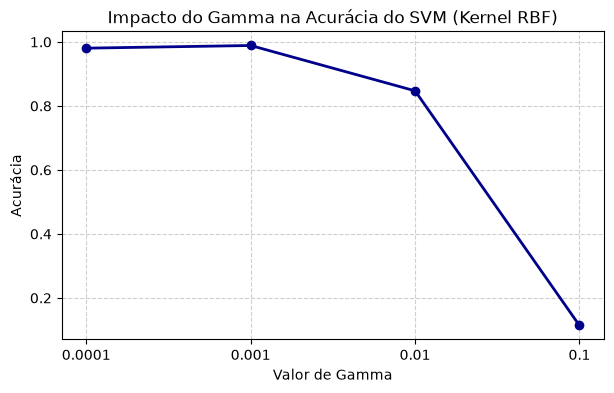

In [ ]:
# Nova rotina de testes
X, y, _ = carregar_dados()
executar_analise_sensibilidade(X, y)